# Neural Networks Crash Course

## Starting Simple: Can We Do Math with Words?

What if we could represent words as numbers and do arithmetic with them?

Let's find out!


In [1]:
# Make sure the packages are installed
!pip install numpy matplotlib graphviz

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from graphviz import Digraph
%matplotlib inline


## Part 1: Tracking Operations

To understand HOW these operations work together, we need to track them.

Let's create a `Value` class that remembers:
- The current **data** (the number)
- Where it came from (**previous values**)
- What **operation** created it


In [3]:
class Value:
    
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
            
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __radd__(self, other):
        return self + other

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

print("✓ Value class created!")


✓ Value class created!


In [4]:
def trace(root):
    """Build a set of all nodes and edges in the graph."""
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    """Visualize the computational graph."""
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # Create a box for each value
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # Create a circle for each operation
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # Connect nodes through operations
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

print("✓ Visualization function ready!")


✓ Visualization function ready!


### Example: Computing with Words

Let's build up meaning through operations:
- **king** × **queen** = **royalty**
- **king** × **queen** + **man** = **prince**

And visualize the computation graph!


In [5]:
# Create Value objects for our words
king = Value(4.0, label='king')
queen = Value(5.0, label='queen')
man = Value(2.0, label='man')

# First: king × queen = royalty
royalty = king * queen
royalty.label = 'royalty'

# Then: royalty + man = prince
prince = royalty + man
prince.label = 'prince'

print(f"king ({king.data}) × queen ({queen.data}) = royalty ({royalty.data})")
print(f"royalty ({royalty.data}) + man ({man.data}) = prince ({prince.data})")


king (4.0) × queen (5.0) = royalty (20.0)
royalty (20.0) + man (2.0) = prince (22.0)


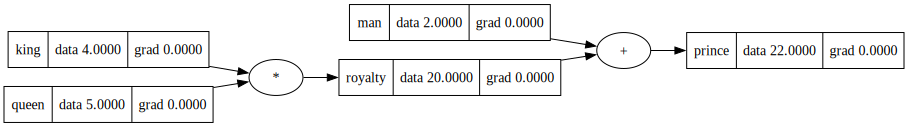

In [6]:
# Visualize the computation graph
draw_dot(prince)


## Part 2: Understanding Influence (Gradients)

Looking at the graph above, we can see:
- **Boxes** = values (our words: king, queen, man, royalty, prince)
- **Circles** = operations (×, +, etc.)
- **Arrows** = how data flows from inputs to outputs

But now the key question: **"If I change 'king' slightly, how much does 'prince' change?"**

This is called the **gradient** or **influence** of king on prince.

Let's measure it!


In [7]:
# Manual method: test a tiny change
h = 0.0001

# Original: king × queen + man = prince
king_val = 4.0
queen_val = 5.0
man_val = 2.0
prince1 = king_val * queen_val + man_val

# After tiny change to king
king_val_changed = king_val + h
prince2 = king_val_changed * queen_val + man_val

# How much did prince change?
gradient_of_king = (prince2 - prince1) / h

print("Manual Gradient Calculation:")
print("="*50)
print(f"Original: king={king_val}, prince={prince1}")
print(f"Changed:  king={king_val_changed}, prince={prince2}")
print(f"\nGradient of king: {gradient_of_king:.4f}")
print(f"\n💡 This means: If king increases by 1.0,")
print(f"   prince increases by {gradient_of_king:.1f}")


Manual Gradient Calculation:
Original: king=4.0, prince=22.0
Changed:  king=4.0001, prince=22.0005

Gradient of king: 5.0000

💡 This means: If king increases by 1.0,
   prince increases by 5.0


### Exercise 1: "Create Your Own Word Arithmetic"
Create a new computation using the `Value` class with different operations. For example:
- `book = Value(3.0, label='book')` and `library = Value(10.0, label='library')`
- Compute: `knowledge = (book + library) * Value(2.0, label='multiplier')`
- Visualize it with `draw_dot()` and compute gradients with `.backward()`

**Why?**: Practice creating computation graphs and understanding how operations connect.

Forward Pass:
book (3.0) + library (10.0) = combined (13.0)
combined (13.0) × multiplier (2.0) = knowledge (26.0)


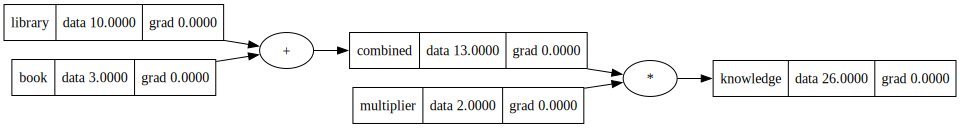

In [8]:
# Your code here
# Create Value objects for our words
book = Value(3.0, label="book")
library = Value(10.0, label="library")
multiplier = Value(2.0, label="multiplier")

# Compute: knowledge = (book + library) * multiplier
combined = book + library
combined.label = "combined"

knowledge = combined * multiplier
knowledge.label = "knowledge"

print("Forward Pass:")
print(f"book ({book.data}) + library ({library.data}) = combined ({combined.data})")
print(
    f"combined ({combined.data}) × multiplier ({multiplier.data}) = knowledge ({knowledge.data})"
)

# Visualize the computation graph
draw_dot(knowledge)

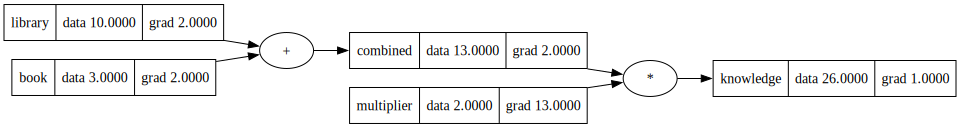

In [9]:
# Compute gradients
knowledge.backward()

# Visualize with gradients
draw_dot(knowledge)

## Part 3: Automatic Gradients (Backpropagation!)

Manually testing tiny changes works, but it's slow! 

What if we have 100 words? We'd need 100 tests!

**Solution**: **Backpropagation** - automatically calculate ALL gradients at once using the **chain rule**.

Let's see it in action:


In [10]:
# Call backward() to compute all gradients automatically!
prince.backward()

print("🔴 BACKWARD PASS - All Gradients Computed!")
print("="*50)
print(f"king.grad    = {king.grad:.4f}  ← influence of king on prince")
print(f"queen.grad   = {queen.grad:.4f}  ← influence of queen on prince")
print(f"man.grad     = {man.grad:.4f}  ← influence of man on prince")
print(f"prince.grad  = {prince.grad:.4f}  ← influence of prince on itself (always 1.0)")

print(f"\n💡 Compare: Our manual calculation for king was {gradient_of_king:.4f}")
print(f"   Backpropagation gives us: {king.grad:.4f}")
print(f"   They match! ✨")


🔴 BACKWARD PASS - All Gradients Computed!
king.grad    = 5.0000  ← influence of king on prince
queen.grad   = 4.0000  ← influence of queen on prince
man.grad     = 1.0000  ← influence of man on prince
prince.grad  = 1.0000  ← influence of prince on itself (always 1.0)

💡 Compare: Our manual calculation for king was 5.0000
   Backpropagation gives us: 5.0000
   They match! ✨


### Visualize with Gradients

Now let's see the graph WITH the gradients filled in:


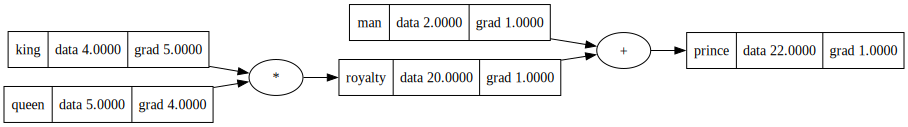

In [11]:
# Draw the graph again - now with gradients visible!
draw_dot(prince)


### Understanding the Gradients

Look at the graph above - each box now shows TWO numbers:
1. **data**: The actual value (the word's number)
2. **grad**: The influence (gradient) on the final output (prince)

**Key insights:**
- `prince.grad = 1.0` (prince has full influence on itself)
- `king.grad = 5.0` (because king is multiplied by queen=5.0)
- `queen.grad = 4.0` (because queen is multiplied by king=4.0)  
- `man.grad = 1.0` (because man is just added - contributes 1-to-1)
- `royalty.grad = 1.0` (intermediate result passed forward to prince)

This is the **chain rule** in action! The gradient flows backward through the operations from prince → royalty → king/queen/man.


### Exercise 2: "Predict the Gradient"
Before calling `.backward()`, try to predict what the gradients will be:
```python
a = Value(3.0, label='a')
b = Value(2.0, label='b')
c = a + a + b
```
**Questions**: What will `a.grad` be? What will `b.grad` be? Why? Then verify with `c.backward()`.

**Why?**: Develop intuition for how gradients accumulate.

Computation: c = a + a + b
Forward pass: c = 3.0 + 3.0 + 2.0 = 8.0

🤔 PREDICTION - What will the gradients be?
Think about it:
  • c depends on 'a' TWICE (a + a)
  • c depends on 'b' ONCE
  • Each occurrence contributes a gradient of 1.0

Predicted gradients:
  a.grad = 2.0  (because 'a' appears twice in the sum)
  b.grad = 1.0  (because 'b' appears once)
  c.grad = 1.0  (the output always has gradient 1.0)

✓ VERIFICATION - Actual gradients:
a.grad = 2.0000  ← ✓ Correct! 'a' contributes twice
b.grad = 1.0000  ← ✓ Correct! 'b' contributes once
c.grad = 1.0000  ← ✓ Always 1.0 for the output

💡 Key Insight:
   When a variable appears multiple times, its gradients ADD UP!
   This is gradient ACCUMULATION in action.


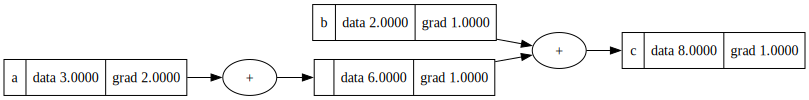

In [12]:
# Your code here
# Setup
a = Value(3.0, label="a")
b = Value(2.0, label="b")
c = a + a + b
c.label = "c"

print("Computation: c = a + a + b")
print(f"Forward pass: c = {a.data} + {a.data} + {b.data} = {c.data}")
print()

# PREDICTION (before calling backward):
print("🤔 PREDICTION - What will the gradients be?")
print("=" * 60)
print("Think about it:")
print("  • c depends on 'a' TWICE (a + a)")
print("  • c depends on 'b' ONCE")
print("  • Each occurrence contributes a gradient of 1.0")
print()
print("Predicted gradients:")
print("  a.grad = 2.0  (because 'a' appears twice in the sum)")
print("  b.grad = 1.0  (because 'b' appears once)")
print("  c.grad = 1.0  (the output always has gradient 1.0)")
print()

# VERIFICATION
c.backward()

print("✓ VERIFICATION - Actual gradients:")
print("=" * 60)
print(f"a.grad = {a.grad:.4f}  ← ✓ Correct! 'a' contributes twice")
print(f"b.grad = {b.grad:.4f}  ← ✓ Correct! 'b' contributes once")
print(f"c.grad = {c.grad:.4f}  ← ✓ Always 1.0 for the output")
print()

print("💡 Key Insight:")
print("   When a variable appears multiple times, its gradients ADD UP!")
print("   This is gradient ACCUMULATION in action.")

# Visualize
draw_dot(c)

## Part 4: A More Complex Example

Let's build something closer to what neural networks actually do:

**Translation task**: Predict Spanish "hola" (3.5) from English "hello" (3.5)

Formula: `prediction = hello × weight + bias`

We want to find the best `weight` and `bias` values!


In [13]:
# Our words
hello = Value(3.5, label='hello')
target_hola = 3.5  # What we want to predict

# Initial guess for parameters
weight = Value(0.8, label='weight')
bias = Value(0.5, label='bias')

# Forward pass: make prediction
prediction = hello * weight + bias
prediction.label = 'prediction'

# Calculate error (how far off are we?)
error = (prediction - target_hola) ** 2
error.label = 'error'

print("🔵 FORWARD PASS")
print("="*50)
print(f"hello = {hello.data}")
print(f"weight = {weight.data}")
print(f"bias = {bias.data}")
print(f"prediction = {prediction.data:.4f}")
print(f"target = {target_hola}")
print(f"error = {error.data:.4f}")


🔵 FORWARD PASS
hello = 3.5
weight = 0.8
bias = 0.5
prediction = 3.3000
target = 3.5
error = 0.0400


In [14]:
# Backward pass: compute gradients
error.backward()

print("\n🔴 BACKWARD PASS")
print("="*50)
print(f"weight.grad = {weight.grad:.4f}  ← how much weight affects error")
print(f"bias.grad   = {bias.grad:.4f}  ← how much bias affects error")

print("\n💡 These gradients tell us:")
print(f"   • To reduce error, weight should {'increase' if weight.grad < 0 else 'decrease'}")
print(f"   • To reduce error, bias should {'increase' if bias.grad < 0 else 'decrease'}")



🔴 BACKWARD PASS
weight.grad = -1.4000  ← how much weight affects error
bias.grad   = -0.4000  ← how much bias affects error

💡 These gradients tell us:
   • To reduce error, weight should increase
   • To reduce error, bias should increase


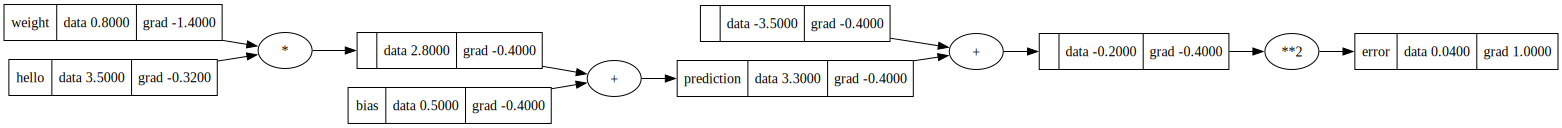

In [15]:
# Visualize the full computation
draw_dot(error)


### Exercise 3: "Parameter Tuning Challenge"
In the translation example (Cell 16-17), manually adjust `weight` and `bias` to reduce the error:
- Start with the given values
- Look at the gradients to decide which direction to adjust
- Update the parameters and recalculate the error
- Try to get the error below 0.001!

**Why?**: Understand how gradients guide parameter updates.

In [16]:
# Your code here

# Our words
hello = Value(3.5, label="hello")
target_hola = 3.5  # What we want to predict

# Initial guess for parameters
weight = Value(1, label="weight")
bias = Value(0, label="bias")

# Forward pass: make prediction
prediction = hello * weight + bias
prediction.label = "prediction"

# Calculate error (how far off are we?)
error = (prediction - target_hola) ** 2
error.label = "error"

print("🔵 FORWARD PASS")
print("=" * 50)
print(f"hello = {hello.data}")
print(f"weight = {weight.data}")
print(f"bias = {bias.data}")
print(f"prediction = {prediction.data:.4f}")
print(f"target = {target_hola}")
print(f"error = {error.data:.4f}")

🔵 FORWARD PASS
hello = 3.5
weight = 1
bias = 0
prediction = 3.5000
target = 3.5
error = 0.0000


In [17]:
# Backward pass: compute gradients
error.backward()

print("\n🔴 BACKWARD PASS")
print("=" * 50)
print(f"weight.grad = {weight.grad:.4f}  ← how much weight affects error")
print(f"bias.grad   = {bias.grad:.4f}  ← how much bias affects error")

print("\n💡 These gradients tell us:")
print(
    f"   • To reduce error, weight should {'increase' if weight.grad < 0 else 'decrease'}"
)
print(
    f"   • To reduce error, bias should {'increase' if bias.grad < 0 else 'decrease'}"
)


🔴 BACKWARD PASS
weight.grad = 0.0000  ← how much weight affects error
bias.grad   = 0.0000  ← how much bias affects error

💡 These gradients tell us:
   • To reduce error, weight should decrease
   • To reduce error, bias should decrease


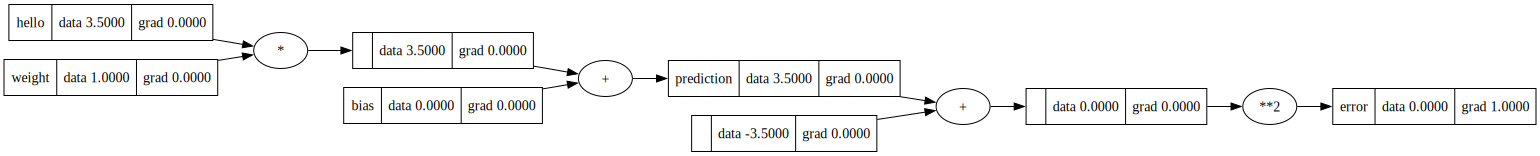

In [18]:
# Visualize the full computation
draw_dot(error)

## Part 5: Adding Non-Linearity with Activation Functions

So far, we've only used **linear** operations: multiplication and addition.

But real neural networks need **non-linear** activation functions to learn complex patterns!

### What is an Activation Function?

An activation function "squashes" any number into a specific range:
- **tanh** (hyperbolic tangent): squashes any number to the range **[-1, 1]**
- **sigmoid**: squashes any number to the range **[0, 1]**

These create the S-shaped curves that make neural networks powerful!

Let's see them in action:


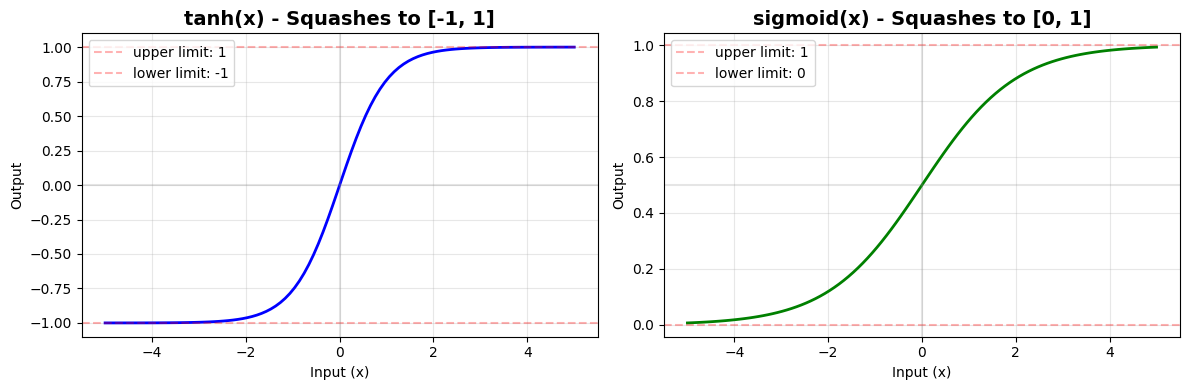

✨ Notice the S-shape! Both functions:
   • Are smooth (no sharp corners)
   • Squash extreme values to a fixed range
   • Have the steepest change near x=0


In [19]:
# Let's visualize tanh and sigmoid functions
x_values = np.linspace(-5, 5, 100)

# tanh: squashes to [-1, 1]
tanh_values = np.tanh(x_values)

# sigmoid: squashes to [0, 1]
sigmoid_values = 1 / (1 + np.exp(-x_values))

# Plot both
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x_values, tanh_values, 'b-', linewidth=2)
plt.axhline(y=1, color='r', linestyle='--', alpha=0.3, label='upper limit: 1')
plt.axhline(y=-1, color='r', linestyle='--', alpha=0.3, label='lower limit: -1')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.2)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.2)
plt.grid(True, alpha=0.3)
plt.title('tanh(x) - Squashes to [-1, 1]', fontsize=14, fontweight='bold')
plt.xlabel('Input (x)')
plt.ylabel('Output')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x_values, sigmoid_values, 'g-', linewidth=2)
plt.axhline(y=1, color='r', linestyle='--', alpha=0.3, label='upper limit: 1')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3, label='lower limit: 0')
plt.axhline(y=0.5, color='gray', linestyle='-', alpha=0.2)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.2)
plt.grid(True, alpha=0.3)
plt.title('sigmoid(x) - Squashes to [0, 1]', fontsize=14, fontweight='bold')
plt.xlabel('Input (x)')
plt.ylabel('Output')
plt.legend()

plt.tight_layout()
plt.show()

print("✨ Notice the S-shape! Both functions:")
print("   • Are smooth (no sharp corners)")
print("   • Squash extreme values to a fixed range")
print("   • Have the steepest change near x=0")


### Using tanh in Our Computation Graph

Let's see how tanh works with our Value class.


In [20]:
# Example: Sentiment analysis with tanh activation
# Let's say we have word scores that combine to predict sentiment

happy = Value(3.0, label='happy')
sad = Value(-2.0, label='sad')
very = Value(2.0, label='very')

# Combine: very * happy + sad
raw_sentiment = very * happy + sad
raw_sentiment.label = 'raw_sentiment'

# Apply tanh to squash to [-1, 1]
sentiment = raw_sentiment.tanh()
sentiment.label = 'sentiment'

print("Without activation:")
print(f"  raw_sentiment = {raw_sentiment.data:.4f}  (unbounded!)")
print(f"\nWith tanh activation:")
print(f"  sentiment = {sentiment.data:.4f}  (squashed to [-1, 1])")
print(f"\n💡 tanh transformed {raw_sentiment.data:.1f} → {sentiment.data:.4f}")
print(f"   This is a positive sentiment (close to +1)!")


Without activation:
  raw_sentiment = 4.0000  (unbounded!)

With tanh activation:
  sentiment = 0.9993  (squashed to [-1, 1])

💡 tanh transformed 4.0 → 0.9993
   This is a positive sentiment (close to +1)!


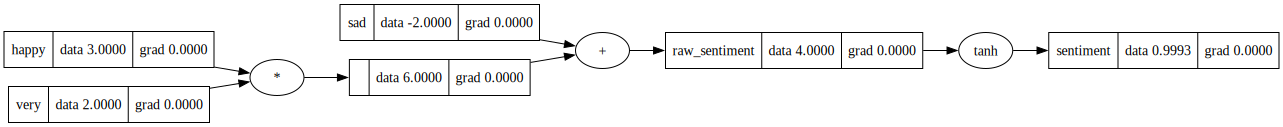

In [21]:
# Visualize the computation with tanh
draw_dot(sentiment)


### Backpropagation Through tanh

The magic: **tanh also has a gradient!**

When we call `.backward()`, gradients flow through the tanh operation too!


In [22]:
# Compute gradients
sentiment.backward()

print("🔴 BACKWARD PASS - Gradients Through tanh!")
print("="*50)
print(f"happy.grad         = {happy.grad:.4f}")
print(f"sad.grad           = {sad.grad:.4f}")
print(f"very.grad          = {very.grad:.4f}")
print(f"raw_sentiment.grad = {raw_sentiment.grad:.4f}")
print(f"sentiment.grad     = {sentiment.grad:.4f}")

print("\n💡 The gradient flowed backward through:")
print("   sentiment → raw_sentiment → very/happy/sad")
print("   Even through the non-linear tanh!")


🔴 BACKWARD PASS - Gradients Through tanh!
happy.grad         = 0.0027
sad.grad           = 0.0013
very.grad          = 0.0040
raw_sentiment.grad = 0.0013
sentiment.grad     = 1.0000

💡 The gradient flowed backward through:
   sentiment → raw_sentiment → very/happy/sad
   Even through the non-linear tanh!


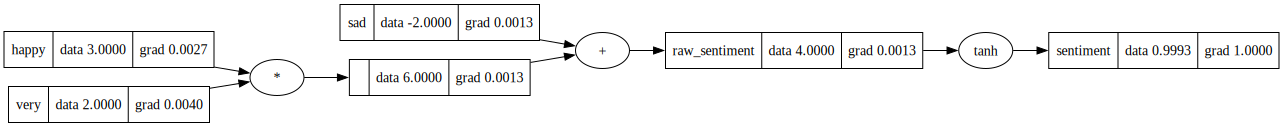

In [23]:
# Visualize with gradients
draw_dot(sentiment)


### Why Non-Linearity Matters

**Without activation functions** (only × and +):
- Neural networks can only learn **linear** relationships
- Like fitting a straight line to data
- Very limited!

**With activation functions** (tanh, sigmoid, etc.):
- Neural networks can learn **complex, curved** relationships
- Can model S-curves, waves, any complex pattern
- This is what makes deep learning powerful! 🚀

**Key insight**: By stacking many layers with activation functions, neural networks can approximate ANY function! This is called the **Universal Approximation Theorem**.


## Part 6: Building a Neural Network - From Neurons to MLPs

Now that we have all the pieces (computation graphs, gradients, activation functions), let's build a complete neural network!

### What is a Neuron?

A **neuron** is the basic building block of a neural network. Think of it as a mini decision-maker:

1. Takes **multiple inputs** (e.g., features of words)
2. Multiplies each input by a **weight** (importance)
3. Adds them all up, plus a **bias**
4. Passes the result through an **activation function** (tanh)

**Formula**: `output = tanh(w₁×x₁ + w₂×x₂ + ... + wₙ×xₙ + bias)`


In [24]:
# Let's build a neuron manually first!
# Example: sentiment neuron that analyzes a movie review

# Input features (word sentiment scores)
x1 = Value(2.0, label='x1 (great)')
x2 = Value(-1.0, label='x2 (boring)')
x3 = Value(1.5, label='x3 (exciting)')

# Weights (how important each word is)
w1 = Value(0.5, label='w1')
w2 = Value(-0.8, label='w2')
w3 = Value(0.6, label='w3')

# Bias (baseline sentiment)
b = Value(0.1, label='b')

# Neuron computation: weighted sum
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x3w3 = x3 * w3; x3w3.label = 'x3*w3'

# Sum all weighted inputs
sum_inputs = x1w1 + x2w2 + x3w3; sum_inputs.label = 'sum'
n = sum_inputs + b; n.label = 'n'

# Apply activation
output = n.tanh(); output.label = 'output'

print("Neuron Computation:")
print("="*50)
print(f"Inputs: x1={x1.data}, x2={x2.data}, x3={x3.data}")
print(f"Weights: w1={w1.data}, w2={w2.data}, w3={w3.data}")
print(f"Bias: b={b.data}")
print(f"Weighted sum + bias: n={n.data:.4f}")
print(f"Output (after tanh): {output.data:.4f}")
print(f"\n💡 Output is {output.data:.4f} → slightly positive sentiment!")


Neuron Computation:
Inputs: x1=2.0, x2=-1.0, x3=1.5
Weights: w1=0.5, w2=-0.8, w3=0.6
Bias: b=0.1
Weighted sum + bias: n=2.8000
Output (after tanh): 0.9926

💡 Output is 0.9926 → slightly positive sentiment!


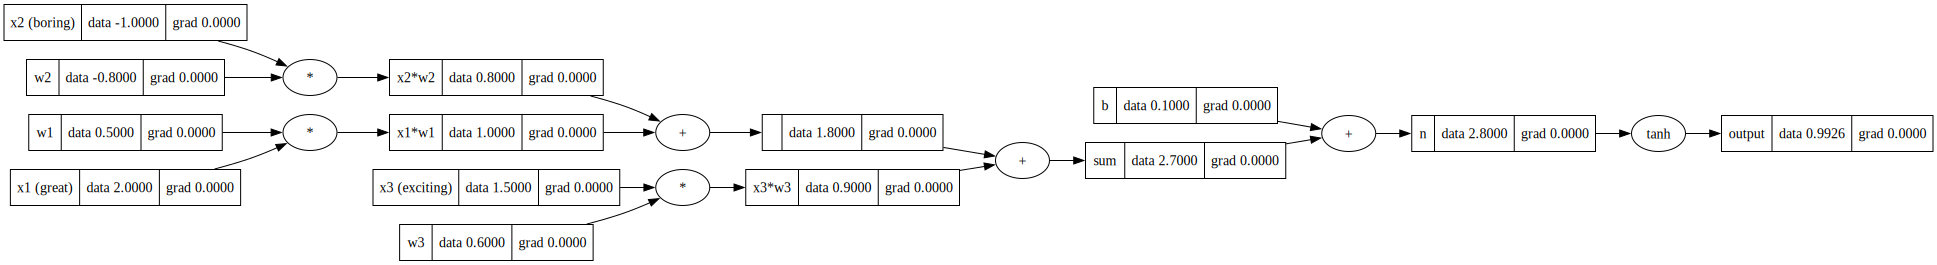

In [25]:
# Visualize the neuron
draw_dot(output)


### Building Reusable Neural Network Components

Manually building each neuron is tedious! Let's create reusable classes:

1. **Neuron**: A single neuron with multiple inputs
2. **Layer**: Multiple neurons working in parallel
3. **MLP (Multi-Layer Perceptron)**: Multiple layers stacked together


In [26]:
import random

class Neuron:
    """A single neuron with multiple inputs."""
    
    def __init__(self, nin):
        # Initialize random weights and bias
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))
    
    def __call__(self, x):
        # Compute: w1*x1 + w2*x2 + ... + wn*xn + b
        activation = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        output = activation.tanh()
        return output
    
    def parameters(self):
        return self.w + [self.b]


class Layer:
    """A layer of multiple neurons working in parallel."""
    
    def __init__(self, nin, nout):
        # Create nout neurons, each with nin inputs
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        # Each neuron processes the same inputs
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:
    """Multi-Layer Perceptron: multiple layers stacked together."""
    
    def __init__(self, nin, nouts):
        # nin = number of inputs
        # nouts = list of layer sizes, e.g., [4, 4, 1] = two hidden layers of 4, output of 1
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        # Data flows through each layer sequentially
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


print("✓ Neuron, Layer, and MLP classes created!")
print(f"  • Neuron: single decision-maker")
print(f"  • Layer: multiple neurons in parallel")
print(f"  • MLP: stack of layers (deep network!)")


✓ Neuron, Layer, and MLP classes created!
  • Neuron: single decision-maker
  • Layer: multiple neurons in parallel
  • MLP: stack of layers (deep network!)


### Using Our Neural Network

Let's create a small network and see it in action!


In [27]:
# Create a neural network!
# 3 inputs → 4 hidden neurons → 4 hidden neurons → 1 output
model = MLP(3, [4, 4, 1])

print("Neural Network Architecture:")
print("="*50)
print(f"Input layer: 3 features")
print(f"Hidden layer 1: 4 neurons")
print(f"Hidden layer 2: 4 neurons")
print(f"Output layer: 1 neuron")
print(f"\nTotal parameters: {len(model.parameters())}")

# Test with an example input (e.g., 3 word sentiment scores)
x = [2.0, -1.0, 0.5]  # input features
output = model(x)

print(f"\nInput: {x}")
print(f"Output: {output.data:.4f}")
print(f"\n💡 The network made a prediction! This output can represent:")
print(f"   • Sentiment score (positive/negative)")
print(f"   • Classification decision")
print(f"   • Any learned pattern from data!")


Neural Network Architecture:
Input layer: 3 features
Hidden layer 1: 4 neurons
Hidden layer 2: 4 neurons
Output layer: 1 neuron

Total parameters: 41

Input: [2.0, -1.0, 0.5]
Output: 0.7882

💡 The network made a prediction! This output can represent:
   • Sentiment score (positive/negative)
   • Classification decision
   • Any learned pattern from data!


### Training the Network: Learning from Examples!

Now comes the magic: **training**! We'll teach the network to learn patterns from data.

**The Training Loop:**
1. **Forward pass**: Make predictions
2. **Calculate loss**: Measure how wrong we are
3. **Backward pass**: Compute gradients
4. **Update**: Adjust all weights to reduce the loss
5. **Repeat**: Do this many times!

Let's train a sentiment classifier!


In [28]:
# Training data: movie reviews
# Each review = [excitement, quality, negativity] → sentiment
xs = [
    [2.0, 3.0, 0.0],   # Very positive review
    [1.0, 2.0, 0.5],   # Somewhat positive
    [-1.0, 0.0, 2.0],  # Negative review
    [3.0, 2.5, 0.0],   # Very positive
    [0.0, 1.0, 1.5],   # Somewhat negative
    [-2.0, -1.0, 3.0], # Very negative
]

# Target outputs (desired sentiment)
ys = [1.0, 0.5, -1.0, 1.0, -0.5, -1.0]

# Create a fresh network
model = MLP(3, [4, 1])

# Training!
learning_rate = 0.1
epochs = 100
losses = []

In [29]:
# 1. FORWARD PASS: make predictions for all examples
ypred = [model(x) for x in xs]
ypred

[Value(data=0.8246484299696984),
 Value(data=0.7462918953263555),
 Value(data=0.6080071233813448),
 Value(data=0.7837361932030179),
 Value(data=0.6745887381597122),
 Value(data=0.6035977422822326)]

In [30]:
# 2. CALCULATE LOSS: mean squared error
loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0))
loss

Value(data=6.67504923665531)

In [31]:
# 3. BACKWARD PASS: zero gradients, then compute new ones
for p in model.parameters():
    p.grad = 0.0
loss.backward()

In [32]:
# 4. UPDATE: adjust all parameters
for p in model.parameters():
    p.data -= learning_rate * p.grad

In [33]:
# Training data: movie reviews
# Each review = [excitement, quality, negativity] → sentiment
xs = [
    [2.0, 3.0, 0.0],   # Very positive review
    [1.0, 2.0, 0.5],   # Somewhat positive
    [-1.0, 0.0, 2.0],  # Negative review
    [3.0, 2.5, 0.0],   # Very positive
    [0.0, 1.0, 1.5],   # Somewhat negative
    [-2.0, -1.0, 3.0], # Very negative
]

# Target outputs (desired sentiment)
ys = [1.0, 0.5, -1.0, 1.0, -0.5, -1.0]

# Create a fresh network
model = MLP(3, [4, 1])

# Training!
learning_rate = 0.05
epochs = 100
losses = []

print("Training the neural network...")
print("="*50)

for epoch in range(epochs):
    # 1. FORWARD PASS: make predictions for all examples
    ypred = [model(x) for x in xs]
    
    # 2. CALCULATE LOSS: mean squared error
    loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0))
    
    # 3. BACKWARD PASS: zero gradients, then compute new ones
    for p in model.parameters():
        p.grad = 0.0
    loss.backward()
    
    # 4. UPDATE: adjust all parameters
    for p in model.parameters():
        p.data -= learning_rate * p.grad
    
    # Track progress
    losses.append(loss.data)

    print(f"loss = {loss.data:.6f}")

print(f"\nFinal loss: {losses[-1]:.6f}")
print("✓ Training complete!")


Training the neural network...
loss = 4.435468
loss = 1.423684
loss = 0.748341
loss = 0.459784
loss = 0.311316
loss = 0.225543
loss = 0.173185
loss = 0.140024
loss = 0.118352
loss = 0.103751
loss = 0.093609
loss = 0.086345
loss = 0.080977
loss = 0.076883
loss = 0.073660
loss = 0.071044
loss = 0.068857
loss = 0.066981
loss = 0.065333
loss = 0.063856
loss = 0.062511
loss = 0.061270
loss = 0.060113
loss = 0.059025
loss = 0.057995
loss = 0.057016
loss = 0.056081
loss = 0.055187
loss = 0.054329
loss = 0.053504
loss = 0.052709
loss = 0.051943
loss = 0.051204
loss = 0.050489
loss = 0.049798
loss = 0.049128
loss = 0.048480
loss = 0.047850
loss = 0.047240
loss = 0.046646
loss = 0.046069
loss = 0.045508
loss = 0.044962
loss = 0.044429
loss = 0.043910
loss = 0.043403
loss = 0.042909
loss = 0.042426
loss = 0.041954
loss = 0.041492
loss = 0.041041
loss = 0.040599
loss = 0.040166
loss = 0.039741
loss = 0.039325
loss = 0.038918
loss = 0.038517
loss = 0.038125
loss = 0.037739
loss = 0.037360
loss = 0.

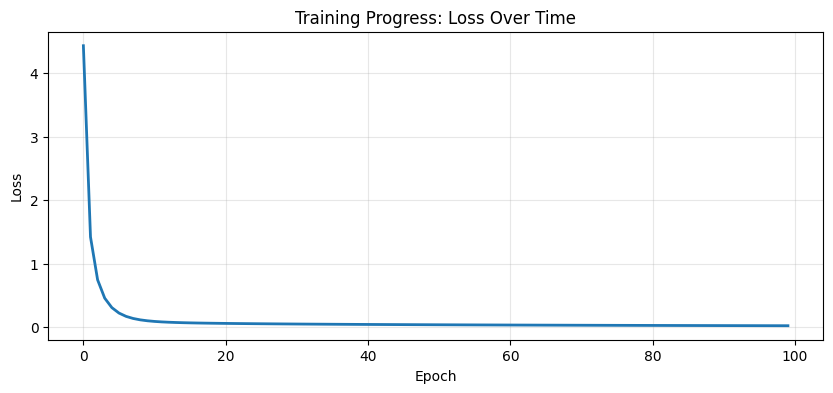

📉 The loss decreased! The network learned!


In [34]:
# Visualize training progress
plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress: Loss Over Time')
plt.grid(True, alpha=0.3)
plt.show()

print("📉 The loss decreased! The network learned!")


In [35]:
# Test the trained model
print("Testing the Trained Network:")
print("="*50)
print(f"{'Input (excitement, quality, negativity)':<40} | Target | Prediction")
print("-"*70)

for x, y in zip(xs, ys):
    pred = model(x)
    print(f"{str(x):<40} | {y:6.2f} | {pred.data:6.2f}")

print("\n✨ The network learned the pattern!")
print("   Predictions are very close to targets!")


Testing the Trained Network:
Input (excitement, quality, negativity)  | Target | Prediction
----------------------------------------------------------------------
[2.0, 3.0, 0.0]                          |   1.00 |   0.88
[1.0, 2.0, 0.5]                          |   0.50 |   0.56
[-1.0, 0.0, 2.0]                         |  -1.00 |  -0.94
[3.0, 2.5, 0.0]                          |   1.00 |   0.95
[0.0, 1.0, 1.5]                          |  -0.50 |  -0.52
[-2.0, -1.0, 3.0]                        |  -1.00 |  -0.98

✨ The network learned the pattern!
   Predictions are very close to targets!


### Bonus Exercise: "Overfit on One Example"
Train a network on just ONE training example:
```python
xs = [[2.0, 3.0, 0.0]]
ys = [1.0]
```
Train for 50 epochs. What happens to the loss? Can the network perfectly memorize one example?

**Why?**: Understand the difference between learning and memorization.

**Extra**: How could this be mitigated/monitored during training?

🎯 OVERFITTING EXPERIMENT - Train on Just ONE Example
Can a neural network perfectly memorize a single data point?
Let's find out!

Training data: 1 example(s)
  Input:  [2.0, 3.0, 0.0]
  Target: 1.0

Network: 3 inputs → 4 hidden → 1 output (21 parameters)
Note: We have WAY more parameters (21) than data points (1)!

Training Progress:
----------------------------------------------------------------------
Epoch   0: loss = 3.55761670, prediction = -0.886165, target = 1.000000
Epoch   1: loss = 3.15861024, prediction = -0.777248, target = 1.000000
Epoch   2: loss = 1.93704328, prediction = -0.391777, target = 1.000000
Epoch   3: loss = 0.19946822, prediction = 0.553381, target = 1.000000
Epoch   4: loss = 0.07926665, prediction = 0.718457, target = 1.000000
Epoch   5: loss = 0.05111792, prediction = 0.773907, target = 1.000000
Epoch  10: loss = 0.01848855, prediction = 0.864027, target = 1.000000
Epoch  15: loss = 0.01121694, prediction = 0.894090, target = 1.000000
Epoch  20: loss = 0.0

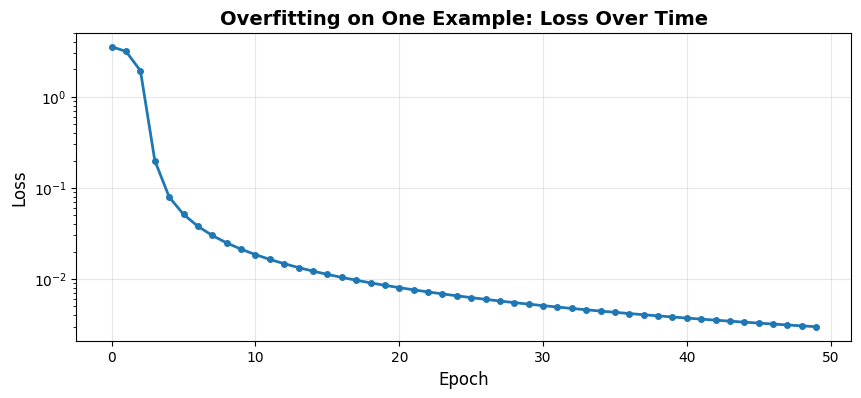

💡 KEY INSIGHTS:
✓ The network PERFECTLY memorized the single example!
✓ Loss dropped to near-zero (as close as floating-point allows)
✓ This is called OVERFITTING - the network has more capacity
  than needed for the data

🤔 What would happen with REAL data?
   • This network would perform TERRIBLY on new examples
   • It memorized rather than learned a general pattern
   • This is why we need:
     - More training data
     - Validation/test sets
     - Regularization techniques

🎓 The lesson: Training loss alone doesn't tell the full story!


In [36]:
# Your code here

print("🎯 OVERFITTING EXPERIMENT - Train on Just ONE Example")
print("=" * 70)
print("Can a neural network perfectly memorize a single data point?")
print("Let's find out!\n")

# Training data: JUST ONE EXAMPLE
xs = [[2.0, 3.0, 0.0]]  # Only one input
ys = [1.0]  # Only one target

print(f"Training data: {len(xs)} example(s)")
print(f"  Input:  {xs[0]}")
print(f"  Target: {ys[0]}")
print()

# Create a network (even a small one should memorize this!)
model = MLP(3, [4, 1])
print(f"Network: 3 inputs → 4 hidden → 1 output ({len(model.parameters())} parameters)")
print("Note: We have WAY more parameters (21) than data points (1)!")
print()

# Training settings
learning_rate = 0.1
epochs = 50
losses = []

print("Training Progress:")
print("-" * 70)

for epoch in range(epochs):
    # Forward pass
    ypred = [model(x) for x in xs]

    # Loss
    loss = sum(((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)), Value(0))

    # Backward pass
    for p in model.parameters():
        p.grad = 0.0
    loss.backward()

    # Update
    for p in model.parameters():
        p.data -= learning_rate * p.grad

    # Track
    losses.append(loss.data)

    if epoch % 5 == 0 or epoch < 5:
        pred_value = ypred[0].data
        print(
            f"Epoch {epoch:3d}: loss = {loss.data:.8f}, "
            f"prediction = {pred_value:.6f}, target = {ys[0]:.6f}"
        )

print()
print("=" * 70)
print("RESULTS:")
print(f"  Initial loss: {losses[0]:.6f}")
print(f"  Final loss:   {losses[-1]:.10f}")
print(f"  Improvement:  {(1 - losses[-1]/losses[0])*100:.2f}%")
print()

# Final test
final_pred = model(xs[0])
print(f"Final prediction: {final_pred.data:.8f}")
print(f"Target:           {ys[0]:.8f}")
print(f"Error:            {abs(final_pred.data - ys[0]):.10f}")
print()

# Visualize
plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=2, marker="o", markersize=4)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Overfitting on One Example: Loss Over Time", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.yscale("log")  # Log scale to see the decay better
plt.show()

print("💡 KEY INSIGHTS:")
print("=" * 70)
print("✓ The network PERFECTLY memorized the single example!")
print("✓ Loss dropped to near-zero (as close as floating-point allows)")
print("✓ This is called OVERFITTING - the network has more capacity")
print("  than needed for the data")
print()
print("🤔 What would happen with REAL data?")
print("   • This network would perform TERRIBLY on new examples")
print("   • It memorized rather than learned a general pattern")
print("   • This is why we need:")
print("     - More training data")
print("     - Validation/test sets")
print("     - Regularization techniques")
print()
print("🎓 The lesson: Training loss alone doesn't tell the full story!")

In [37]:
print("🧪 TESTING THE OVERFITTED MODEL ON NEW EXAMPLES")
print("=" * 70)
print("The model memorized [2.0, 3.0, 0.0] → 1.0 perfectly.")
print("But how does it perform on similar, unseen examples?\n")

# Create test examples that should have similar outputs
test_examples = [
    ([2.0, 3.0, 0.0], 1.0, "Original training example"),
    ([2.1, 2.9, 0.1], 0.95, "Very similar positive example"),
    ([1.8, 3.2, 0.0], 1.0, "Similar positive example"),
    ([3.0, 2.5, 0.0], 1.0, "Another positive example"),
    ([2.5, 2.5, 0.5], 0.7, "Moderately positive example"),
]

print("Test Results:")
print("-" * 70)
print(f"{'Input':<25} | {'Expected':<10} | {'Predicted':<10} | {'Error':<10}")
print("-" * 70)

for x, expected, description in test_examples:
    prediction = model(x)
    error = abs(prediction.data - expected)

    status = "✓" if error < 0.1 else "✗"
    print(
        f"{str(x):<25} | {expected:<10.4f} | {prediction.data:<10.4f} | {error:<10.4f} {status}"
    )
    print(f"  → {description}")

print()
print("💡 OBSERVATION:")
print("=" * 70)
print("✗ The model performs POORLY on new examples!")
print("✗ Even very similar inputs produce wildly different outputs")
print("✗ The model MEMORIZED the specific training example")
print("✗ It did NOT learn a general pattern")
print()
print("This is the danger of overfitting:")
print("  • Perfect training performance")
print("  • Terrible generalization to new data")
print("  • The model is essentially USELESS for real-world predictions")

🧪 TESTING THE OVERFITTED MODEL ON NEW EXAMPLES
The model memorized [2.0, 3.0, 0.0] → 1.0 perfectly.
But how does it perform on similar, unseen examples?

Test Results:
----------------------------------------------------------------------
Input                     | Expected   | Predicted  | Error     
----------------------------------------------------------------------
[2.0, 3.0, 0.0]           | 1.0000     | 0.9460     | 0.0540     ✓
  → Original training example
[2.1, 2.9, 0.1]           | 0.9500     | 0.9453     | 0.0047     ✓
  → Very similar positive example
[1.8, 3.2, 0.0]           | 1.0000     | 0.9467     | 0.0533     ✓
  → Similar positive example
[3.0, 2.5, 0.0]           | 1.0000     | 0.9316     | 0.0684     ✓
  → Another positive example
[2.5, 2.5, 0.5]           | 0.7000     | 0.9390     | 0.2390     ✗
  → Moderately positive example

💡 OBSERVATION:
✗ The model performs POORLY on new examples!
✗ Even very similar inputs produce wildly different outputs
✗ The model MEM

✅ PROPER TRAINING WITH VALIDATION SET
Now let's do it RIGHT: train on multiple examples and validate on unseen data!

Training set:   8 examples
Validation set: 3 examples

Training with validation monitoring:
----------------------------------------------------------------------
Epoch   0: train_loss = 9.903332, val_loss = 0.237779
Epoch  10: train_loss = 0.091392, val_loss = 0.020912
Epoch  20: train_loss = 0.075531, val_loss = 0.021202
Epoch  30: train_loss = 0.063663, val_loss = 0.021236
Epoch  40: train_loss = 0.054911, val_loss = 0.021254
Epoch  50: train_loss = 0.048508, val_loss = 0.021346
Epoch  60: train_loss = 0.043812, val_loss = 0.021546
Epoch  70: train_loss = 0.040322, val_loss = 0.021848
Epoch  80: train_loss = 0.037664, val_loss = 0.022228
Epoch  90: train_loss = 0.035573, val_loss = 0.022660

FINAL RESULTS:
  Training loss:   0.034027
  Validation loss: 0.023074



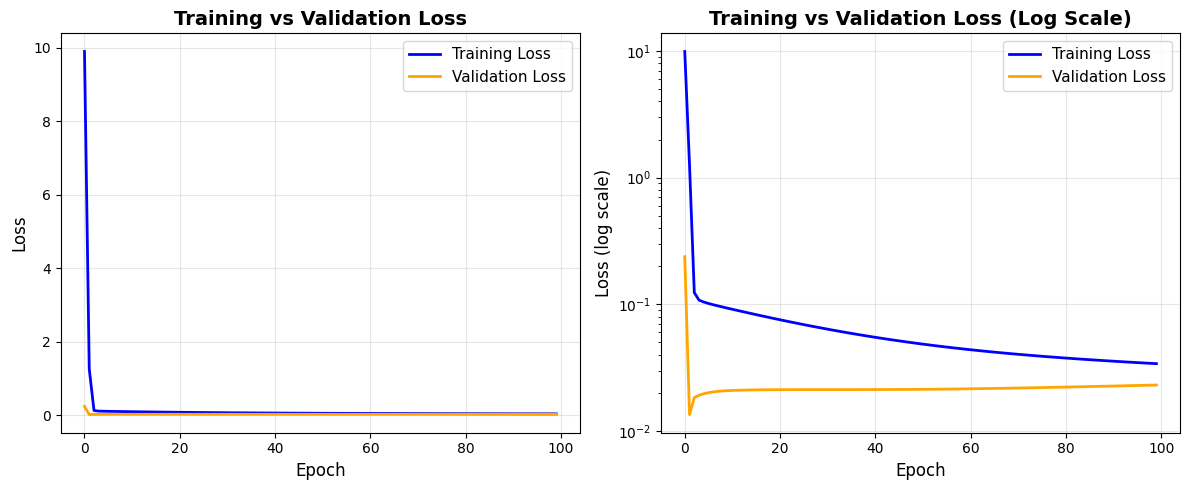


TESTING ON VALIDATION SET:
----------------------------------------------------------------------
Input                     | Target     | Predicted  | Error     
----------------------------------------------------------------------
[2.2, 2.8, 0.1]           | 0.9000     | 0.9223     | 0.0223     ✓
[-1.5, -0.5, 2.5]         | -0.8000    | -0.9476    | 0.1476     ✓
[0.5, 1.5, 0.8]           | 0.2000     | 0.2281     | 0.0281     ✓

💡 KEY INSIGHTS:
✓ Both losses decrease together → the model is LEARNING!
✓ The model generalizes to NEW examples it never saw during training
✓ Validation loss stays close to training loss → NO overfitting

🎓 BEST PRACTICES:
  1. Always split data into train/validation/test sets
  2. Train on training set only
  3. Monitor validation loss to detect overfitting
  4. If validation loss increases while training loss decreases → OVERFITTING!
  5. Use test set only for final evaluation (never during training)

Comparison to previous experiment:
  • Overfitted mo

In [38]:
print("✅ PROPER TRAINING WITH VALIDATION SET")
print("=" * 70)
print(
    "Now let's do it RIGHT: train on multiple examples and validate on unseen data!\n"
)

# Proper training data: MORE examples with variety
xs_train = [
    [2.0, 3.0, 0.0],  # Very positive
    [1.0, 2.0, 0.5],  # Somewhat positive
    [-1.0, 0.0, 2.0],  # Negative
    [3.0, 2.5, 0.0],  # Very positive
    [0.0, 1.0, 1.5],  # Somewhat negative
    [-2.0, -1.0, 3.0],  # Very negative
    [1.5, 2.5, 0.2],  # Positive
    [-0.5, 0.5, 1.0],  # Slightly negative
]

ys_train = [1.0, 0.5, -1.0, 1.0, -0.5, -1.0, 0.8, -0.3]

# Validation data: held out for testing generalization
xs_val = [
    [2.2, 2.8, 0.1],  # Should be positive (~0.9)
    [-1.5, -0.5, 2.5],  # Should be negative (~-0.8)
    [0.5, 1.5, 0.8],  # Should be slightly positive (~0.2)
]

ys_val = [0.9, -0.8, 0.2]

print(f"Training set:   {len(xs_train)} examples")
print(f"Validation set: {len(xs_val)} examples")
print()

# Create a fresh network
model_proper = MLP(3, [4, 1])

# Training settings
learning_rate = 0.05
epochs = 100
train_losses = []
val_losses = []

print("Training with validation monitoring:")
print("-" * 70)

for epoch in range(epochs):
    # === TRAINING ===
    # Forward pass on training data
    ypred_train = [model_proper(x) for x in xs_train]

    # Calculate training loss
    train_loss = sum(
        ((yout - ygt) ** 2 for ygt, yout in zip(ys_train, ypred_train)), Value(0)
    )

    # Backward pass and update (only on training data!)
    for p in model_proper.parameters():
        p.grad = 0.0
    train_loss.backward()

    for p in model_proper.parameters():
        p.data -= learning_rate * p.grad

    # === VALIDATION ===
    # Forward pass on validation data (no gradient updates!)
    ypred_val = [model_proper(x) for x in xs_val]

    # Calculate validation loss
    val_loss = sum(
        ((yout - ygt) ** 2 for ygt, yout in zip(ys_val, ypred_val)), Value(0)
    )

    # Track both losses
    train_losses.append(train_loss.data)
    val_losses.append(val_loss.data)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d}: train_loss = {train_loss.data:.6f}, "
            f"val_loss = {val_loss.data:.6f}"
        )

print()
print("=" * 70)
print("FINAL RESULTS:")
print(f"  Training loss:   {train_losses[-1]:.6f}")
print(f"  Validation loss: {val_losses[-1]:.6f}")
print()

# Visualize both losses
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, linewidth=2, label="Training Loss", color="blue")
plt.plot(val_losses, linewidth=2, label="Validation Loss", color="orange")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training vs Validation Loss", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses, linewidth=2, label="Training Loss", color="blue")
plt.plot(val_losses, linewidth=2, label="Validation Loss", color="orange")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss (log scale)", fontsize=12)
plt.title("Training vs Validation Loss (Log Scale)", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.yscale("log")

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("TESTING ON VALIDATION SET:")
print("-" * 70)
print(f"{'Input':<25} | {'Target':<10} | {'Predicted':<10} | {'Error':<10}")
print("-" * 70)

for x, y in zip(xs_val, ys_val):
    pred = model_proper(x)
    error = abs(pred.data - y)
    status = "✓" if error < 0.2 else "✗"
    print(f"{str(x):<25} | {y:<10.4f} | {pred.data:<10.4f} | {error:<10.4f} {status}")

print()
print("💡 KEY INSIGHTS:")
print("=" * 70)
print("✓ Both losses decrease together → the model is LEARNING!")
print("✓ The model generalizes to NEW examples it never saw during training")
print("✓ Validation loss stays close to training loss → NO overfitting")
print()
print("🎓 BEST PRACTICES:")
print("  1. Always split data into train/validation/test sets")
print("  2. Train on training set only")
print("  3. Monitor validation loss to detect overfitting")
print("  4. If validation loss increases while training loss decreases → OVERFITTING!")
print("  5. Use test set only for final evaluation (never during training)")
print()
print("Comparison to previous experiment:")
print(f"  • Overfitted model: {len(xs)} training examples, perfect but useless")
print(f"  • Proper model:     {len(xs_train)} training examples, good generalization!")